# Surface Code Decoding Pipeline

This notebook demonstrates the modular QEC pipeline:
- Surface code circuit generation with configurable noise
- Pluggable decoder interface
- Logical error rate estimation with confidence intervals
- Threshold plot comparison across decoders

In [8]:
import stim
import pymatching
print(stim.__version__)
print(pymatching.__version__)

1.15.0
2.3.1


In [9]:
from qec_surface.decoders import UnionFindDecoder
from qec_surface.circuits import build_surface_code, NoiseModel
from qec_surface.benchmark import estimate_logical_error_rate

sc = build_surface_code(distance=3, rounds=3, noise=NoiseModel.uniform(0.01))
result = estimate_logical_error_rate(sc, UnionFindDecoder, n_samples=500)
print(result.logical_error_rate)

0.018


In [10]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from qec_surface.circuits import build_surface_code, NoiseModel
from qec_surface.decoders import MWPMDecoder, UnionFindDecoder, BeliefPropagationDecoder, BPOSDDecoder
from qec_surface.benchmark import estimate_logical_error_rate, sweep_noise_levels, compare_decoders

noise = NoiseModel.uniform(0.01)
sc = build_surface_code(distance=3, rounds=3, noise=noise)
print(sc)

SurfaceCodeCircuit(type=surface_code:rotated_memory_x, d=3, rounds=3, noise=[depol=0.0100, meas=0.0100, reset=0.0100])


## 1. Inspect a single circuit

Before running experiments, it's useful to inspect what stim actually generates.
The rotated surface code has d² data qubits and d²-1 ancilla qubits.

SurfaceCodeCircuit(type=surface_code:rotated_memory_x, d=3, rounds=3, noise=[depol=0.0100, meas=0.0100, reset=0.0100])
Data qubits:    9
Ancilla qubits: 8
DEM errors:     76


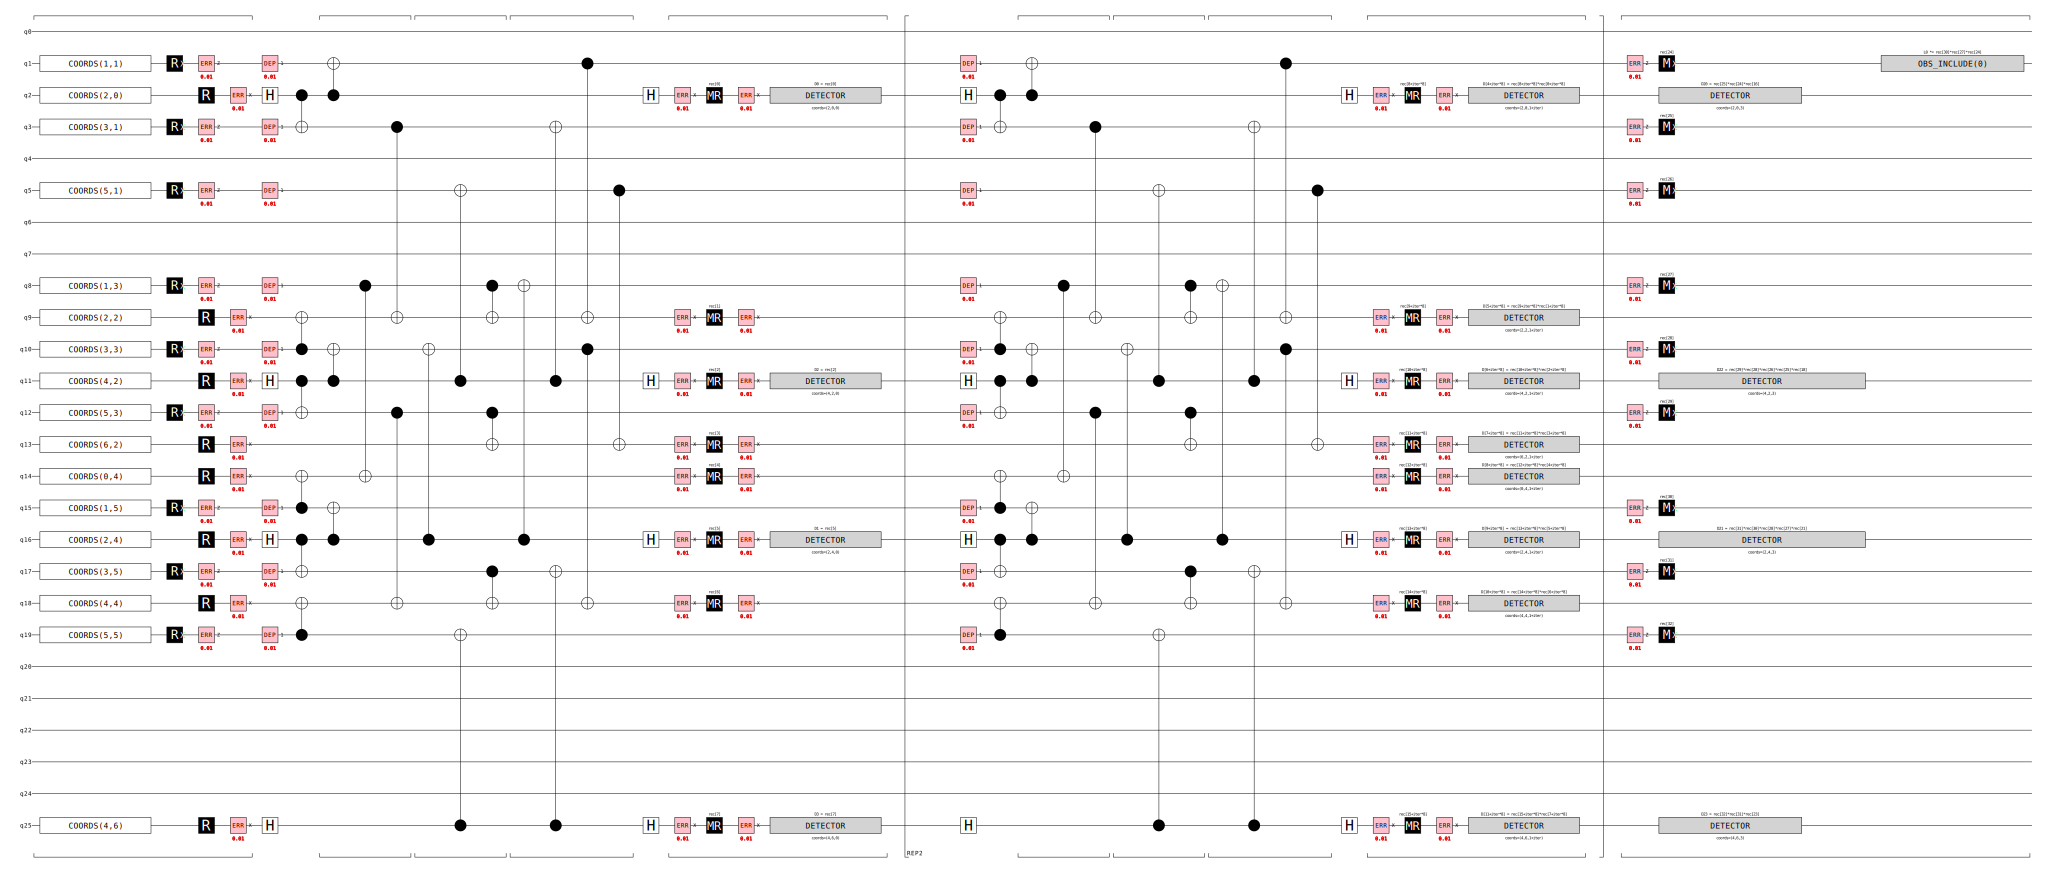

In [11]:
sc = build_surface_code(
    distance=3,
    rounds=3,
    noise=NoiseModel.uniform(0.01)
)
print(sc)
print(f"Data qubits:    {sc.n_data_qubits}")
print(f"Ancilla qubits: {sc.n_ancilla_qubits}")
print(f"DEM errors:     {sc.detector_error_model().num_errors}")

# Visualize the circuit timeline (renders in Jupyter)
sc.circuit.diagram('timeline-svg')

## 2. MWPM threshold sweep

The threshold is the noise level where curves for different distances cross.
For depolarizing circuit-level noise on the rotated surface code,
theory and simulation give p_th ≈ 1% (Fowler et al. 2012).

In [12]:
distances = [3, 5, 7]
noise_levels = [0.001, 0.003, 0.007, 0.01, 0.02, 0.05]
N_SAMPLES = 5_000

df_mwpm = sweep_noise_levels(
    distances=distances,
    noise_levels=noise_levels,
    decoder_cls=MWPMDecoder,
    n_samples=N_SAMPLES,
)

  d=3, p=0.0010 → LER=0.0000 ± 0.0004 (0/5000)
  d=3, p=0.0030 → LER=0.0014 ± 0.0011 (7/5000)
  d=3, p=0.0070 → LER=0.0064 ± 0.0022 (32/5000)
  d=3, p=0.0100 → LER=0.0148 ± 0.0034 (74/5000)
  d=3, p=0.0200 → LER=0.0540 ± 0.0063 (270/5000)
  d=3, p=0.0500 → LER=0.2170 ± 0.0114 (1085/5000)
  d=5, p=0.0010 → LER=0.0000 ± 0.0004 (0/5000)
  d=5, p=0.0030 → LER=0.0000 ± 0.0004 (0/5000)
  d=5, p=0.0070 → LER=0.0024 ± 0.0014 (12/5000)
  d=5, p=0.0100 → LER=0.0034 ± 0.0017 (17/5000)
  d=5, p=0.0200 → LER=0.0338 ± 0.0050 (169/5000)
  d=5, p=0.0500 → LER=0.2752 ± 0.0124 (1376/5000)
  d=7, p=0.0010 → LER=0.0000 ± 0.0004 (0/5000)
  d=7, p=0.0030 → LER=0.0000 ± 0.0004 (0/5000)
  d=7, p=0.0070 → LER=0.0002 ± 0.0005 (1/5000)
  d=7, p=0.0100 → LER=0.0012 ± 0.0010 (6/5000)
  d=7, p=0.0200 → LER=0.0258 ± 0.0044 (129/5000)
  d=7, p=0.0500 → LER=0.3480 ± 0.0132 (1740/5000)


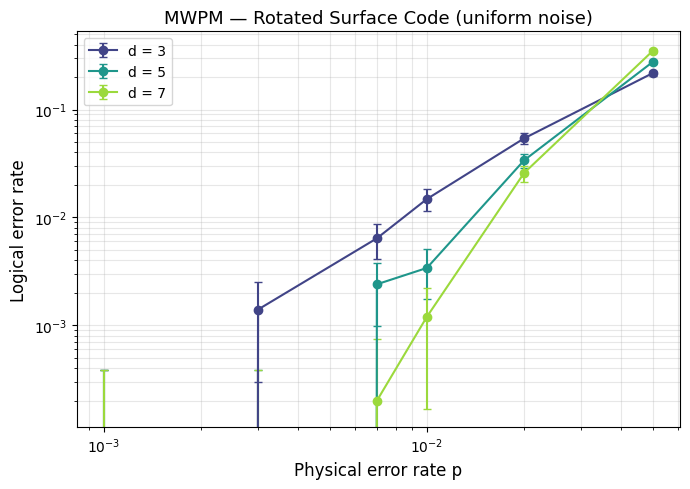

In [13]:
def plot_threshold(df, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = cm.viridis(np.linspace(0.2, 0.85, len(df['distance'].unique())))

    for color, d in zip(colors, sorted(df['distance'].unique())):
        sub = df[df['distance'] == d].sort_values('noise_level')
        ax.errorbar(
            sub['noise_level'],
            sub['logical_error_rate'],
            yerr=sub['error_bar'],
            marker='o', capsize=3, label=f'd = {d}', color=color
        )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Physical error rate p', fontsize=12)
    ax.set_ylabel('Logical error rate', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_threshold(df_mwpm, 'MWPM — Rotated Surface Code (uniform noise)')

## 3. Decoder comparison

Compare MWPM, Union-Find, and BP on the same noise sweep.

Expected behavior:
- **MWPM**: highest threshold (~1%)
- **Union-Find**: slightly lower threshold, but faster per shot
- **BP**: noticeably lower threshold due to short cycles in the surface code Tanner graph
- **BP+OSD**: close to MWPM, but much slower

In [14]:
# Use a single distance to make the comparison fast
COMPARISON_DISTANCE = 5

df_comparison = compare_decoders(
    distances=[COMPARISON_DISTANCE],
    noise_levels=noise_levels,
    decoder_classes=[MWPMDecoder, UnionFindDecoder, BeliefPropagationDecoder, BPOSDDecoder],
    n_samples=N_SAMPLES,
)


── Decoder: MWPMDecoder ──
  d=5, p=0.0010 → LER=0.0000 ± 0.0004 (0/5000)
  d=5, p=0.0030 → LER=0.0000 ± 0.0004 (0/5000)
  d=5, p=0.0070 → LER=0.0014 ± 0.0011 (7/5000)
  d=5, p=0.0100 → LER=0.0050 ± 0.0020 (25/5000)
  d=5, p=0.0200 → LER=0.0362 ± 0.0052 (181/5000)
  d=5, p=0.0500 → LER=0.2910 ± 0.0126 (1455/5000)

── Decoder: UnionFindDecoder ──
  d=5, p=0.0010 → LER=0.0000 ± 0.0004 (0/5000)
  d=5, p=0.0030 → LER=0.0000 ± 0.0004 (0/5000)
  d=5, p=0.0070 → LER=0.0016 ± 0.0012 (8/5000)
  d=5, p=0.0100 → LER=0.0044 ± 0.0019 (22/5000)
  d=5, p=0.0200 → LER=0.0366 ± 0.0052 (183/5000)
  d=5, p=0.0500 → LER=0.2848 ± 0.0125 (1424/5000)

── Decoder: BeliefPropagationDecoder ──
  d=5, p=0.0010 → LER=0.0004 ± 0.0007 (2/5000)
  d=5, p=0.0030 → LER=0.0014 ± 0.0011 (7/5000)
  d=5, p=0.0070 → LER=0.0122 ± 0.0031 (61/5000)
  d=5, p=0.0100 → LER=0.0298 ± 0.0047 (149/5000)
  d=5, p=0.0200 → LER=0.1390 ± 0.0096 (695/5000)
  d=5, p=0.0500 → LER=0.4368 ± 0.0137 (2184/5000)

── Decoder: BPOSDDecoder ──


d:\Games1\qc comp\surface_code_decoders\.venv\Lib\site-packages\ldpc\_legacy_ldpc_v1\_legacy_bposd_decoder.py:45: UserWarning: This is the old syntax for the `bposd_decoder` from `ldpc v1`. Use the `BpOsdDecoder` class from `ldpc v2` for additional features.
  warnings.warn(


  d=5, p=0.0010 → LER=0.0000 ± 0.0004 (0/5000)
  d=5, p=0.0030 → LER=0.0002 ± 0.0005 (1/5000)
  d=5, p=0.0070 → LER=0.0012 ± 0.0010 (6/5000)
  d=5, p=0.0100 → LER=0.0016 ± 0.0012 (8/5000)
  d=5, p=0.0200 → LER=0.0254 ± 0.0044 (127/5000)
  d=5, p=0.0500 → LER=0.2594 ± 0.0121 (1297/5000)


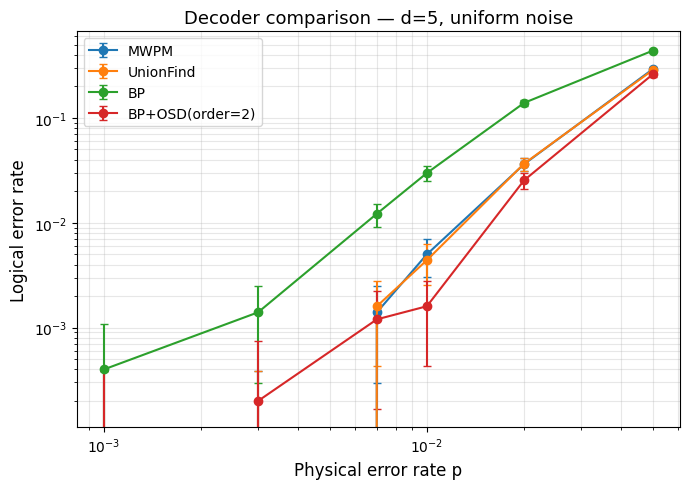

In [15]:
def plot_decoder_comparison(df, distance, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    sub = df[df['distance'] == distance]

    for decoder_name in sub['decoder_name'].unique():
        d_sub = sub[sub['decoder_name'] == decoder_name].sort_values('noise_level')
        ax.errorbar(
            d_sub['noise_level'],
            d_sub['logical_error_rate'],
            yerr=d_sub['error_bar'],
            marker='o', capsize=3, label=decoder_name
        )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Physical error rate p', fontsize=12)
    ax.set_ylabel('Logical error rate', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_decoder_comparison(
    df_comparison,
    distance=COMPARISON_DISTANCE,
    title=f'Decoder comparison — d={COMPARISON_DISTANCE}, uniform noise'
)

## 4. Noise model comparison (same decoder)

How does the threshold change when measurement errors dominate vs gate errors?

This is physically relevant: superconducting qubits often have measurement
fidelity as the bottleneck, while trapped ions typically have worse 2-qubit gates.

  d=3, p=0.0010 → LER=0.0006 ± 0.0008 (3/5000)
  d=3, p=0.0030 → LER=0.0008 ± 0.0009 (4/5000)
  d=3, p=0.0070 → LER=0.0070 ± 0.0023 (35/5000)
  d=3, p=0.0100 → LER=0.0158 ± 0.0035 (79/5000)
  d=3, p=0.0200 → LER=0.0540 ± 0.0063 (270/5000)
  d=3, p=0.0500 → LER=0.2138 ± 0.0114 (1069/5000)
  d=5, p=0.0010 → LER=0.0000 ± 0.0004 (0/5000)
  d=5, p=0.0030 → LER=0.0000 ± 0.0004 (0/5000)
  d=5, p=0.0070 → LER=0.0022 ± 0.0014 (11/5000)
  d=5, p=0.0100 → LER=0.0060 ± 0.0022 (30/5000)
  d=5, p=0.0200 → LER=0.0380 ± 0.0053 (190/5000)
  d=5, p=0.0500 → LER=0.2794 ± 0.0124 (1397/5000)
  d=7, p=0.0010 → LER=0.0000 ± 0.0004 (0/5000)
  d=7, p=0.0030 → LER=0.0000 ± 0.0004 (0/5000)
  d=7, p=0.0070 → LER=0.0004 ± 0.0007 (2/5000)
  d=7, p=0.0100 → LER=0.0012 ± 0.0010 (6/5000)
  d=7, p=0.0200 → LER=0.0222 ± 0.0041 (111/5000)
  d=7, p=0.0500 → LER=0.3348 ± 0.0131 (1674/5000)
  d=3, p=0.0010 → LER=0.0000 ± 0.0004 (0/5000)
  d=3, p=0.0030 → LER=0.0002 ± 0.0005 (1/5000)
  d=3, p=0.0070 → LER=0.0014 ± 0.0011 (7/

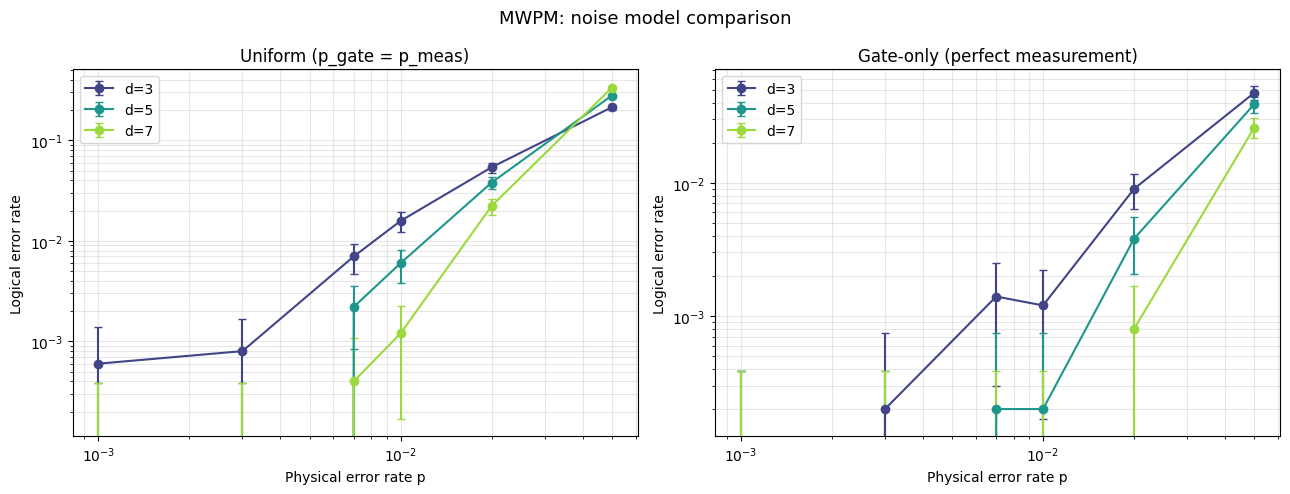

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
noise_models = {
    'Uniform (p_gate = p_meas)': NoiseModel.uniform,
    'Gate-only (perfect measurement)': NoiseModel.gate_only,
}

for ax, (label, factory) in zip(axes, noise_models.items()):
    colors = cm.viridis(np.linspace(0.2, 0.85, len(distances)))
    df = sweep_noise_levels(
        distances=distances,
        noise_levels=noise_levels,
        decoder_cls=MWPMDecoder,
        n_samples=N_SAMPLES,
        noise_factory=factory,
    )
    for color, d in zip(colors, sorted(df['distance'].unique())):
        sub = df[df['distance'] == d].sort_values('noise_level')
        ax.errorbar(
            sub['noise_level'], sub['logical_error_rate'],
            yerr=sub['error_bar'], marker='o', capsize=3,
            label=f'd={d}', color=color
        )
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Physical error rate p')
    ax.set_ylabel('Logical error rate')
    ax.set_title(label)
    ax.legend(); ax.grid(True, which='both', alpha=0.3)

plt.suptitle('MWPM: noise model comparison', fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
from qec_surface.decoders import MWPMDecoder, UnionFindDecoder, BeliefPropagationDecoder, BPOSDDecoder
from qec_surface.benchmark import compare_decoders
from qec_surface.circuits import NoiseModel

df = compare_decoders(
    distances=[5],
    noise_levels=[0.005, 0.01, 0.02, 0.05],
    decoder_classes=[MWPMDecoder, UnionFindDecoder, BeliefPropagationDecoder, BPOSDDecoder],
    n_samples=1000,
)
print(df[["decoder_name", "noise_level", "logical_error_rate"]])


── Decoder: MWPMDecoder ──
  d=5, p=0.0050 → LER=0.0000 ± 0.0019 (0/1000)
  d=5, p=0.0100 → LER=0.0050 ± 0.0048 (5/1000)
  d=5, p=0.0200 → LER=0.0300 ± 0.0107 (30/1000)
  d=5, p=0.0500 → LER=0.2840 ± 0.0279 (284/1000)

── Decoder: UnionFindDecoder ──
  d=5, p=0.0050 → LER=0.0010 ± 0.0027 (1/1000)
  d=5, p=0.0100 → LER=0.0080 ± 0.0058 (8/1000)
  d=5, p=0.0200 → LER=0.0390 ± 0.0121 (39/1000)
  d=5, p=0.0500 → LER=0.2800 ± 0.0278 (280/1000)

── Decoder: BeliefPropagationDecoder ──


d:\Games1\qc comp\surface_code_decoders\.venv\Lib\site-packages\ldpc\_legacy_ldpc_v1\_legacy_bp_decoder.py:46: UserWarning: This is the old syntax for the `bp_decoder` from `ldpc v1`. Use the `BpDecoder` class from `ldpc v2` for additional features.
  warnings.warn(


  d=5, p=0.0050 → LER=0.0020 ± 0.0034 (2/1000)
  d=5, p=0.0100 → LER=0.0290 ± 0.0105 (29/1000)
  d=5, p=0.0200 → LER=0.1340 ± 0.0211 (134/1000)
  d=5, p=0.0500 → LER=0.4360 ± 0.0307 (436/1000)

── Decoder: BPOSDDecoder ──


d:\Games1\qc comp\surface_code_decoders\.venv\Lib\site-packages\ldpc\_legacy_ldpc_v1\_legacy_bposd_decoder.py:45: UserWarning: This is the old syntax for the `bposd_decoder` from `ldpc v1`. Use the `BpOsdDecoder` class from `ldpc v2` for additional features.
  warnings.warn(


  d=5, p=0.0050 → LER=0.0010 ± 0.0027 (1/1000)
  d=5, p=0.0100 → LER=0.0020 ± 0.0034 (2/1000)
  d=5, p=0.0200 → LER=0.0270 ± 0.0102 (27/1000)
  d=5, p=0.0500 → LER=0.2480 ± 0.0267 (248/1000)
       decoder_name  noise_level  logical_error_rate
0              MWPM        0.005               0.000
1              MWPM        0.010               0.005
2              MWPM        0.020               0.030
3              MWPM        0.050               0.284
4         UnionFind        0.005               0.001
5         UnionFind        0.010               0.008
6         UnionFind        0.020               0.039
7         UnionFind        0.050               0.280
8                BP        0.005               0.002
9                BP        0.010               0.029
10               BP        0.020               0.134
11               BP        0.050               0.436
12  BP+OSD(order=2)        0.005               0.001
13  BP+OSD(order=2)        0.010               0.002
14  BP+OSD(ord